In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [181]:
items =  pd.read_csv('/Users/fabian/Documents/Ecom/03-10-25(examen)/Items.csv')
customers =  pd.read_csv('/Users/fabian/Documents/Ecom/03-10-25(examen)/customers.csv')
orders = pd.read_csv('/Users/fabian/Documents/Ecom/03-10-25(examen)/orders.csv')
order_item =  pd.read_csv('/Users/fabian/Documents/Ecom/03-10-25(examen)/order_item.csv')

In [183]:
## copy data
items_df = items.copy()
customers_df = customers.copy()
orders_df = orders.copy()
order_item_df = order_item.copy()

## Data Preparation:
Make sure to use copy() of the original datasets in all data preparation
actions.
1. Handle duplicate data in item dataset:
- . In item dataset duplicate data is one of the following:
i. Same item name and same item brand.
ii. Same item name and no brand vs with brand (meaning
item has the same name but 1 row with brand and 1
without.
- . In case you find duplicate data, remove the item with less
information. Make sure you change associations in other
data sets to the duplicated item id so your data will still be
accurate.

In [186]:
## Exe 1 ## - handle duplicate item & item_brand columns 
duplicate_item_rows = items_df[items_df.duplicated(['item_name',"item_brand"], keep=False)]
duplicate_item_rows

,id,item_name,item_category,item_price,stock_quantity,item_brand,item_availability


In [188]:
## Remove duplicate item according to logic
items_ids_map = {8: 49}
items_df.set_index('id', inplace=True)

In [196]:
items_df.drop(items_ids_map.keys(), axis=0, inplace=True)
items_df.reset_index('id', inplace=True)

In [198]:
## replace removed item id with the items that we didn't remove
order_item_df["item_id"] = order_item_df["item_id"].replace(items_ids_map)
order_item_df[order_item_df["item_id"]== 8]

,Unnamed: 0,id,order_id,item_id,quantity


2. Handle duplicate data in customer dataset:
a. In customer dataset duplicate data is on of the following:
- . Customer with the same email address:
- b. In case you find duplicate data, remove the customer with
less information. Make sure you change associations in other
data sets to the duplicated customer id so your data will still
be accurate.

In [200]:
duplicate_email_rows = customers_df[customers_df.duplicated('email', keep=False)]
duplicate_email_rows
# no email duplicate :

,id,first_name,last_name,gender,age,nationallity,joining_date,phone_number,email


3. Handle missing data in all datasets:
a. In case the missing data in a specific column is above 5% fill
the missing data with a default valid value of your choice
b. In case the missing data is below 5% remove the row from
your calculations and make sure to adjust your other
datasets accordingly.
c. In case you found a row with missing data with a mandatory
column (like id, name, etc…) remove this row from your
dataset.

In [202]:
## missing data in items:
items_df.dropna(subset=["stock_quantity"], inplace=True) # dont habe the item in the stock so i drop from the df 
items_df["item_category"] = items_df["item_category"].fillna("Unknow")
items_df["item_brand"] = items_df["item_brand"].fillna("Unknow")
# drop rows from order_item_df that are pointing to the missing data 
order_item_df = order_item_df[order_item_df["item_id"].isin(items_df["id"])]


In [204]:
## missing data in customers:
customers_df["gender"] = customers_df["gender"].fillna("Unknow")
customers_df["age"] = customers_df["age"].fillna(round(customers_df["age"].mean()))
customers_df['joining_date'] = pd.to_datetime(customers_df['joining_date'])
mean_date = customers_df['joining_date'].median()
mean_date
customers_df["joining_date"] = customers_df["joining_date"].fillna(mean_date)


In [206]:
## missing data in orders:
orders_df["delivery_days"] = orders_df["delivery_days"].fillna(round(orders_df["delivery_days"].mean()))
orders_df.dropna(subset=["customer_id"], inplace=True) # dont habe the customer_ID important information so i do dropna 


In [210]:
## missing data in order_item:
missing_data = order_item_df.isnull().sum()
percentage_missing = order_item_df.isnull().sum() * 100 / items_df.isnull().count() 
total_rows = order_item_df.isnull().count()
final_missing_data = pd.concat([total_rows, missing_data, percentage_missing], axis=1, keys=['Total Rows', 'Missing Rows', 'Precent'])
final_missing_data
    
## no missing data 

,Total Rows,Missing Rows,Precent
Unnamed: 0,838.0,0.0,NaN
id,838.0,0.0,0.0
order_id,838.0,0.0,NaN
item_id,838.0,0.0,NaN
quantity,838.0,0.0,NaN
item_availability,NaN,NaN,NaN
item_brand,NaN,NaN,NaN
item_category,NaN,NaN,NaN
item_name,NaN,NaN,NaN
item_price,NaN,NaN,NaN


# Data analysis:
Use the copy() datasets from your data preparation answer and answer
the following questions
1. Explore the customers.csv dataset and answer the following
questions, base your answers with data calculations and
visualizations if needed:

In [213]:
## A). Count the number of customers by gender, show a
# dataframe with each gender type and how many customers
# we have from that type.
# Plot bar chart to visualize your result.
df_gender_count = customers_df.groupby('gender').size()
df_gender_count = df_gender_count.reset_index(name='count')
df_gender_count


,gender,count
0,Agender,13
1,Bigender,5
2,Female,203
3,Genderfluid,12
4,Genderqueer,5
5,Male,196
6,Non-binary,7
7,Polygender,6
8,Unknow,53


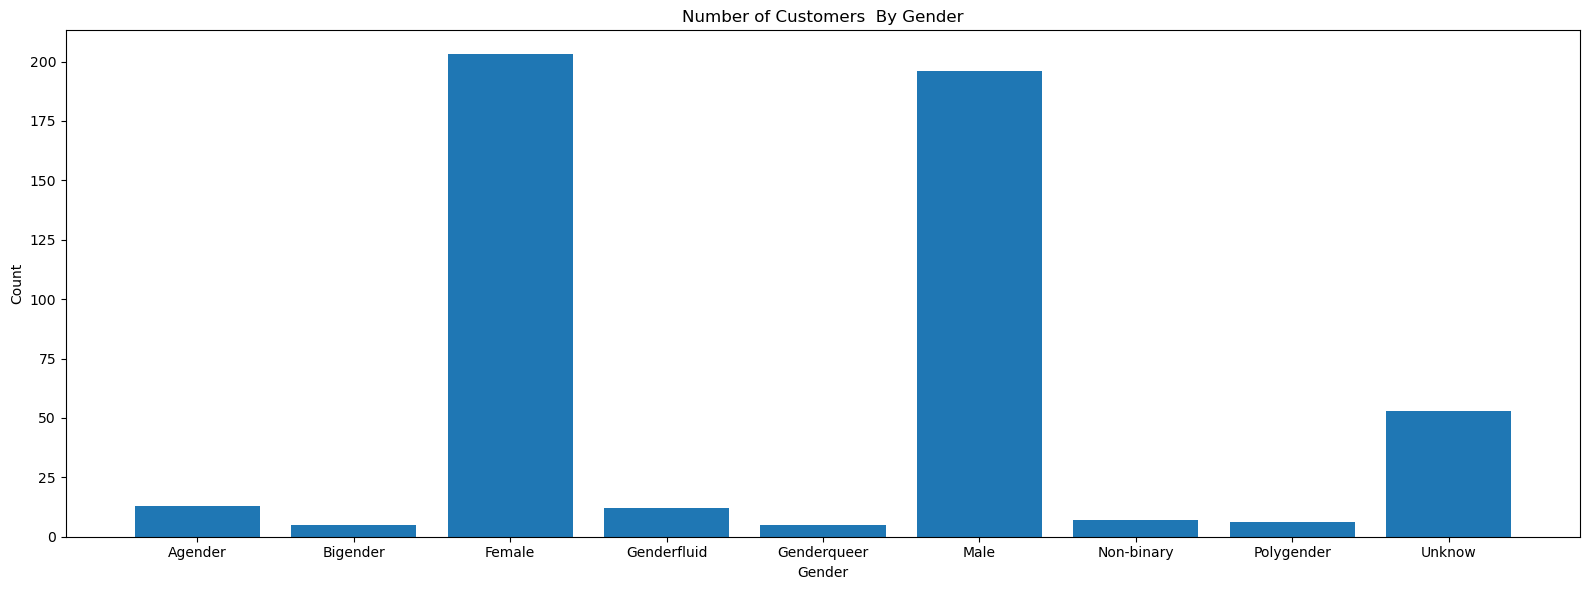

In [215]:
# Bar Chart
plt.figure(figsize=(16, 6))
plt.bar(df_gender_count['gender'], df_gender_count['count'])
plt.title('Number of Customers  By Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

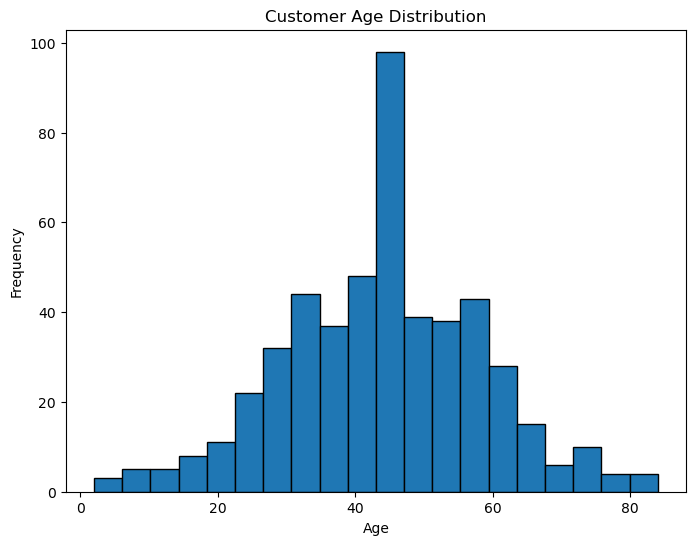

In [217]:
## B). Plot the customer age distribution with histogram chart.:
plt.figure(figsize=(8, 6))
plt.hist(customers_df['age'], bins=20, edgecolor='black')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [219]:
## C). Find what is the year with most joining customers to the company.
customers_df['joining_year'] = customers_df['joining_date'].dt.year
joining_year_counts = customers_df['joining_year'].value_counts()
print(f"Year with most joining customers: {joining_year_counts.idxmax()}")

Year with most joining customers: 2021


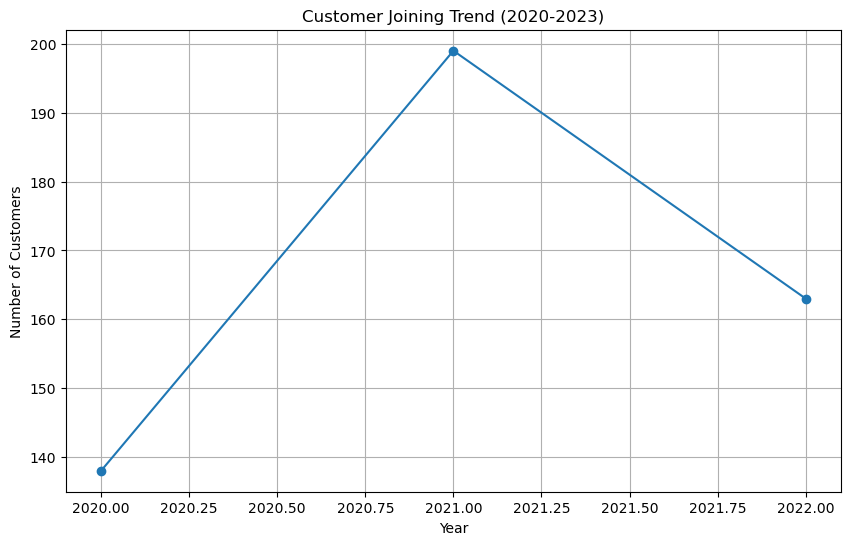

According to the graph we can see that there is an increase in customers who Joined in the year 2021


In [221]:
## D). Examine whether there's a prevailing trend in customer
# joining over the timeframe from 2020 to 2023. Has there
# been a consistent increase or decrease in the number of
# customers joining over the years, or does the data suggest a
# more sporadic or unpredictable pattern?
plt.figure(figsize=(10, 6))
joining_year_counts.sort_index().plot(marker='o')
plt.title('Customer Joining Trend (2020-2023)')
plt.xlabel('Year')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.show()
print(f"According to the graph we can see that there is an increase in customers who Joined in the year 2021")

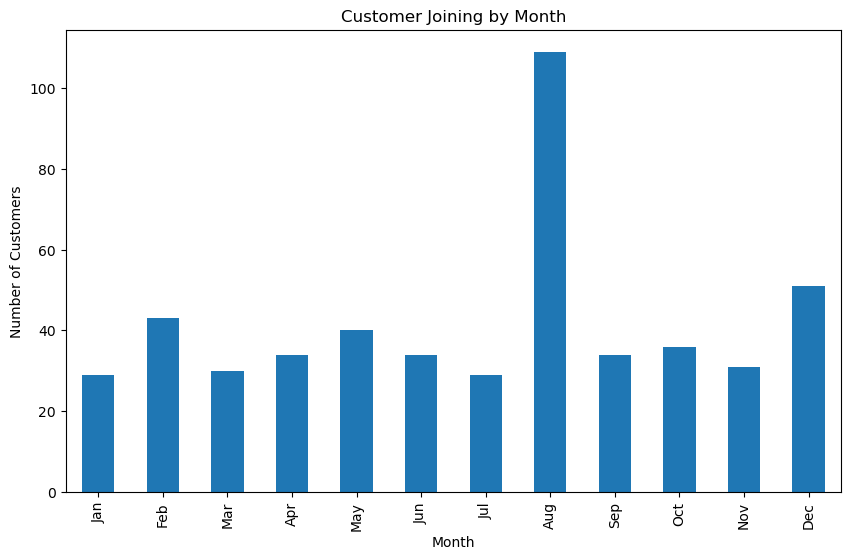

In [223]:
## E). Identify if there's a particular month that consistently sees a
# higher number of new customers. Is there a specific time of
# year when more customers tend to join, suggesting some
# kind of seasonality in customer sign-ups across all the years
# in this dataset?
customers_df['joining_month'] = customers_df['joining_date'].dt.month
joining_month_counts = customers_df['joining_month'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
joining_month_counts.plot(kind='bar')
plt.title('Customer Joining by Month')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

2. Explore the items.csv dataset and answer the following questions,
base your answers with data calculations and visualizations if
needed:

In [226]:
## A). Count the number of items by category, show a dataframe
# with each category and how many items are associated with
# that category.
# Plot bar chart to visualize your result.
count_by_category = items_df.groupby(items_df["item_category"]).size()
count_by_category = count_by_category.reset_index(name="count")
count_by_category

,item_category,count
0,Audio Equipment,2
1,Cables,1
2,Computers and Accessories,7
3,Gaming Equipment,2
4,Mobile Devices and Accessories,7
5,Network Equipment,1
6,Photography Equipment,5
7,Printers and Office Equipment,6
8,Storage Devices,1
9,Televisions and Displays,4


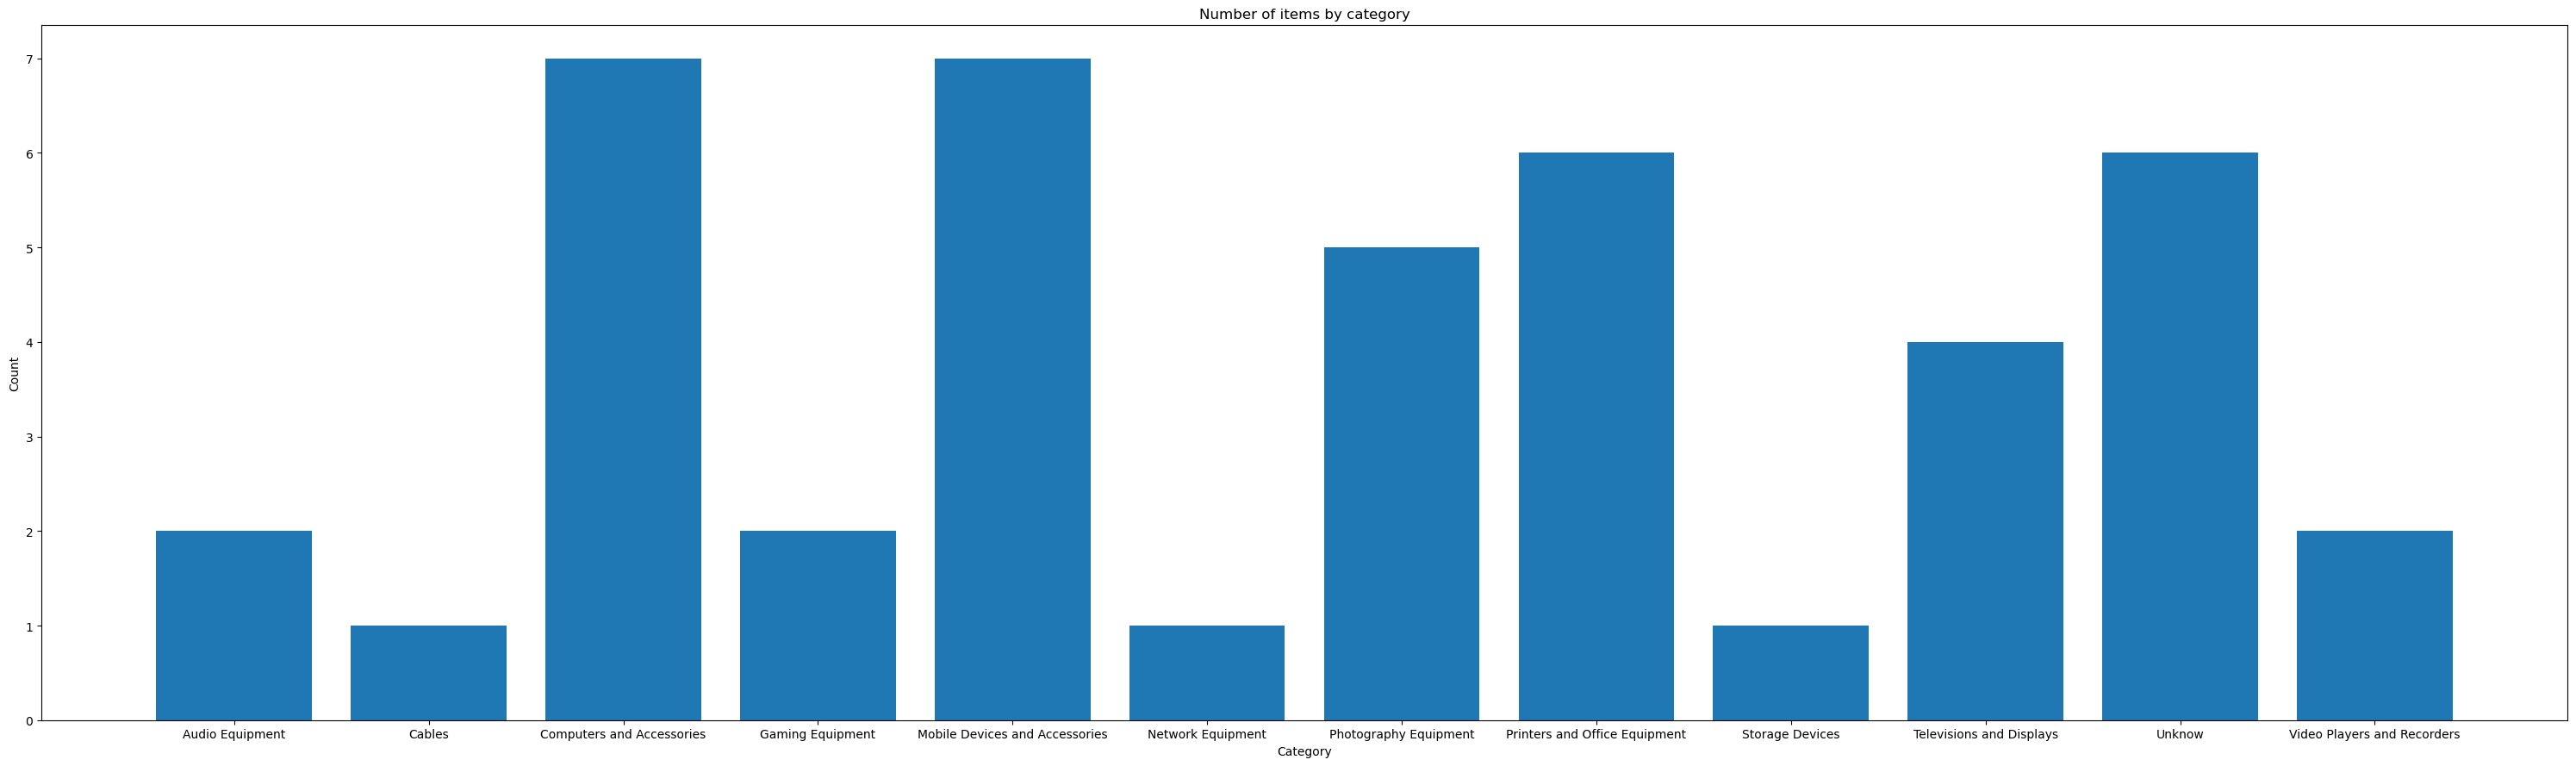

In [281]:
plt.figure(figsize=(30, 9))
plt.bar(count_by_category["item_category"],count_by_category["count"])
plt.title("Number of items by category")
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [230]:
## B). Create a new dataframe containing the item with largest
# quantity in stock and the lowest quantity in stock, in case you
# put default values for missing data don’t use those items in
# your calculations.

max_quantity = items_df.loc[items_df['stock_quantity'].idxmax()]
min_quantity = items_df.loc[items_df['stock_quantity'].idxmin()]
new_df = pd.DataFrame([max_quantity, min_quantity])
## new_df = new_df[["item_name","stock_quantity"]] ## onlie item_name & stock_quantity
new_df

,id,item_name,item_category,item_price,stock_quantity,item_brand,item_availability
39,41,VR Headset,Unknow,1905.01,1367.0,JBL,True
33,35,Wi-Fi Router,Network Equipment,3812.53,14.0,Microsoft,True


In [232]:
## C). Calculate the mean quantity in stock of all items, in case you
# put default values for missing data don’t use those items in
# your calculations.

print(f"The mean quantity in stock for all items is:{items_df["stock_quantity"].mean()} ")


The mean quantity in stock for all items is:746.4318181818181 


3. Explore the orders.csv dataset and answer the following
questions, base your answers with data calculations and
visualizations if needed:

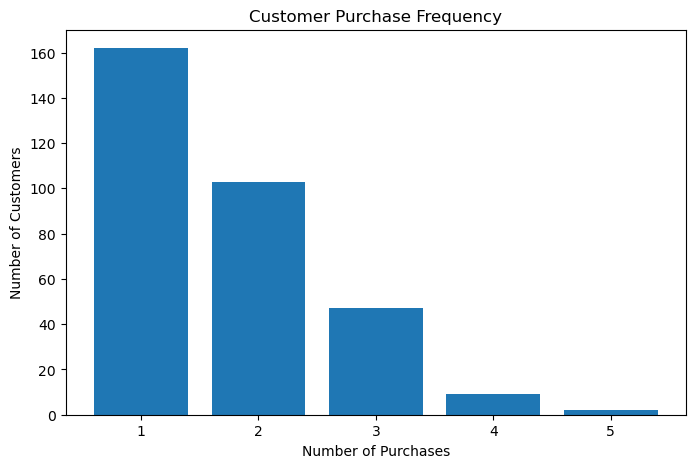

In [237]:
## A). Calculate the amount of customers who have made just a
# single purchase, those who have made two, three, four
# purchases, and so forth.
# Plot bar chart to visualize your result.


orders_per_customer = orders_df.groupby('customer_id').size().reset_index(name='count')

purchase_frequency = orders_per_customer['count'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(purchase_frequency.index, purchase_frequency.values)
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.title('Customer Purchase Frequency')
plt.show()


In [239]:
## B). Find the top 5 customers (customer id, first name and last
# name) that ordered the most orders.

customer_order_counts = orders_df['customer_id'].value_counts().head(5).index

top_customers = customers_df[customers_df['id'].isin(customer_order_counts)][['id', 'first_name', 'last_name']]
top_customers

,id,first_name,last_name
58,59,Merill,Lacroutz
137,138,Ellary,Ledner
150,151,Giorgio,Mence
273,274,Pace,Crookshanks
491,492,Adore,Doel


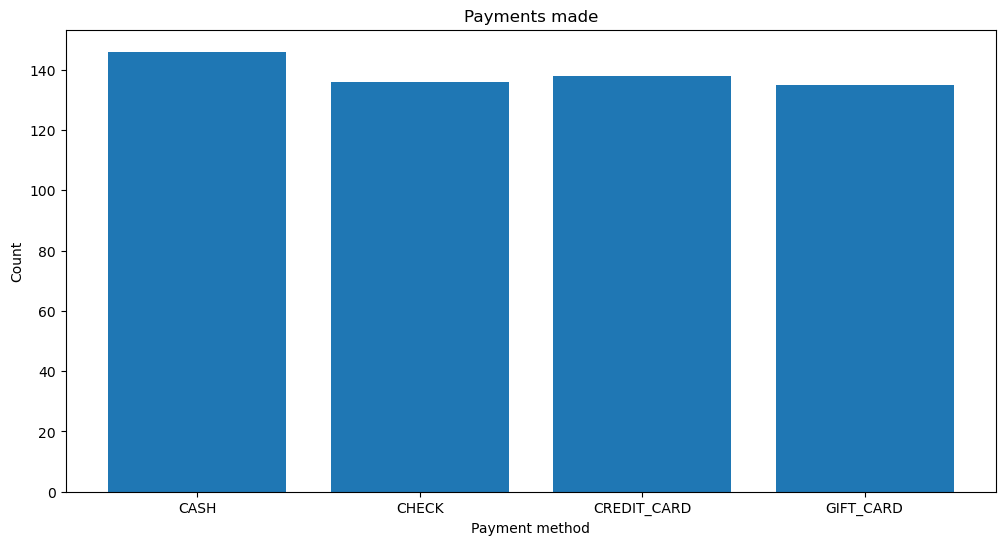

In [241]:
## C). Calculate for each payment method how many customers
# are paying with it.
# Plot bar chart to visualize your result.

payment_methods = orders_df.groupby(["payment_method"]).size()
payment_methods = payment_methods.reset_index(name="Count")
payment_methods

plt.figure(figsize=(12,6))
plt.bar(payment_methods['payment_method'], payment_methods['Count'])
plt.title('Payments made')
plt.xlabel('Payment method')
plt.ylabel('Count')
plt.show()

4. Use all datasets and unser the following questions:

In [273]:
## A). Add a new column to the orders.csv dataset that show the
# total price of each order.



In [ ]:
## B). Use the total_price column you calculated in the previous
# exercise and show what is the max, min and mean of the
# orders total price.

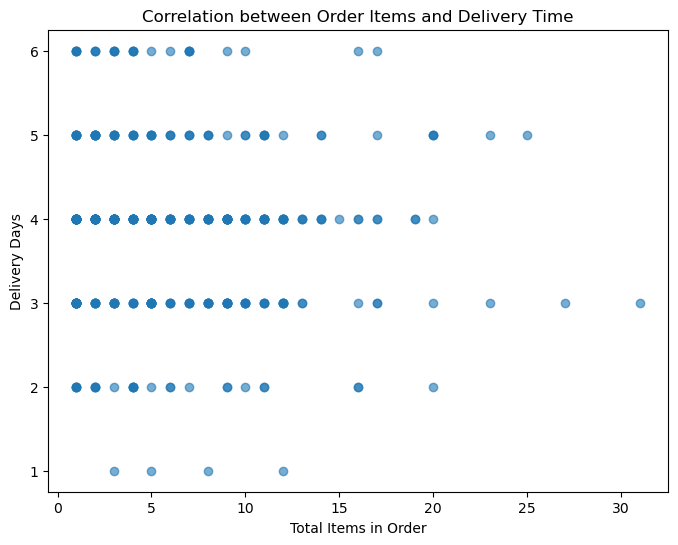

Correlation coefficient between total items and delivery days:-0.05097201518601226 , there its not relationated 


In [267]:
## C). Investigate if there is a correlation between the number of
# items in order and the delivery time (more items meaning
# more delivery time?)
# Use a scatter plot to support your answer.

order_items_count = order_item_df.groupby('order_id')['quantity'].sum().reset_index()
order_items_count.rename(columns={'quantity': 'total_items'}, inplace=True)
#merge
orders_merged = orders_df.merge(order_items_count, on='order_id', how='left')

plt.figure(figsize=(8, 6))
plt.scatter(orders_merged['total_items'], orders_merged['delivery_days'], alpha=0.6)
plt.xlabel('Total Items in Order')
plt.ylabel('Delivery Days')
plt.title('Correlation between Order Items and Delivery Time')
plt.show()

#correlation
corr_coef = orders_merged['total_items'].corr(orders_merged['delivery_days'])
print(f"Correlation coefficient between total items and delivery days:{corr_coef} , there its not relationated ")


In [269]:
## D). Find how many customers never created any order.
customers_with_orders = orders_df['customer_id'].unique()
customers_without_orders = customers_df[~customers_df['id'].isin(customers_with_orders)]
print("Number of customers who never created any order:", len(customers_without_orders))

Number of customers who never created any order: 177


In [277]:
## E). Find what are the top 5 items that has been ordered the
# lowest (in your calculations consider the item quantity in the order)
